In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Here clearly shows females had a much higher survival rate than males                                                                      
### -This supports the “women first” evacuation behavior

In [5]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

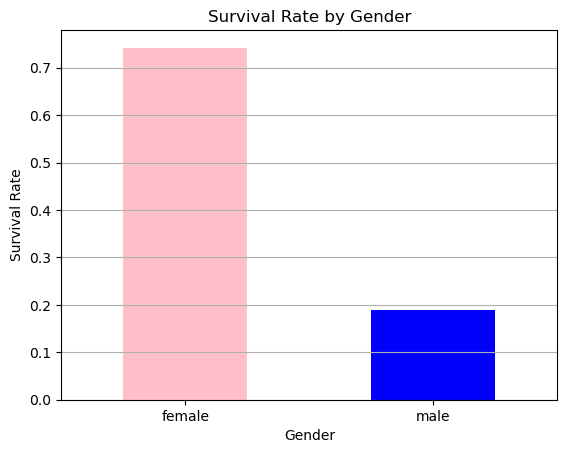

In [9]:
import matplotlib.pyplot as plt

survival_by_sex = df.groupby('Sex')['Survived'].mean()

survival_by_sex.plot(kind='bar', color=['pink', 'blue'])

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

### The graph shows a clear relationship between passenger class and survival rate. First-class passengers had the highest survival rate, while third-class passengers had the lowest. This suggests that socioeconomic status played a major role in survival, likely due to better access to lifeboats and faster evacuation.

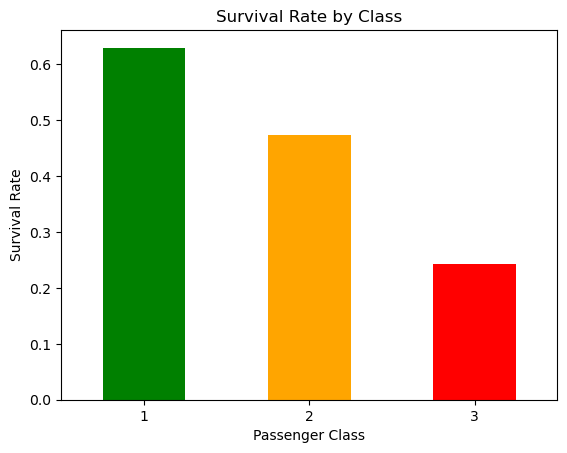

In [14]:
import matplotlib.pyplot as plt

df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar',
    color=['green', 'orange', 'red']  # 1st, 2nd, 3rd
)

plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)

plt.show()

# Survival by Gender and Class

#### The chart shows that females had higher survival rates than males across all passenger classes. First-class passengers survived the most, while third-class passengers had the lowest survival rates. This indicates that both gender and social class influenced survival, with gender being the stronger factor.

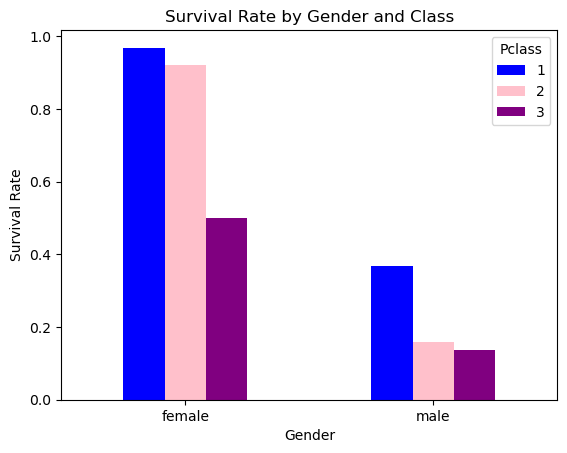

In [15]:
import matplotlib.pyplot as plt

combined = df.groupby(['Sex','Pclass'])['Survived'].mean().unstack()

# This makes:
# rows = Sex (male, female)
# columns = Pclass (1,2,3)

combined.plot(kind='bar', color=['blue','pink','purple'])

plt.title('Survival Rate by Gender and Class')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)

plt.show()

## Line graph for survival rate and age comparison 

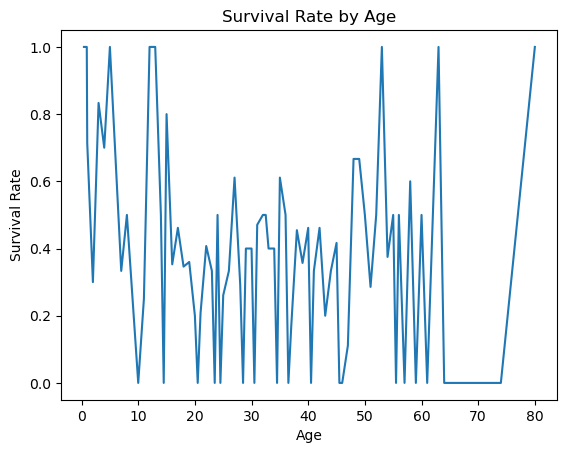

In [17]:
df_age = df.copy()
df_age['Age'] = df_age['Age'].fillna(df_age['Age'].median())

df_age.groupby('Age')['Survived'].mean().plot(kind='line')

plt.title('Survival Rate by Age')
plt.xlabel('Age')
plt.ylabel('Survival Rate')
plt.show()

# Correlation Heat map

### The correlation heatmap shows how different variables relate to each other. It highlights that gender has a strong impact on survival, while passenger class is negatively related, meaning lower-class passengers were less likely to survive. This helps identify the most important factors affecting survival outcomes.

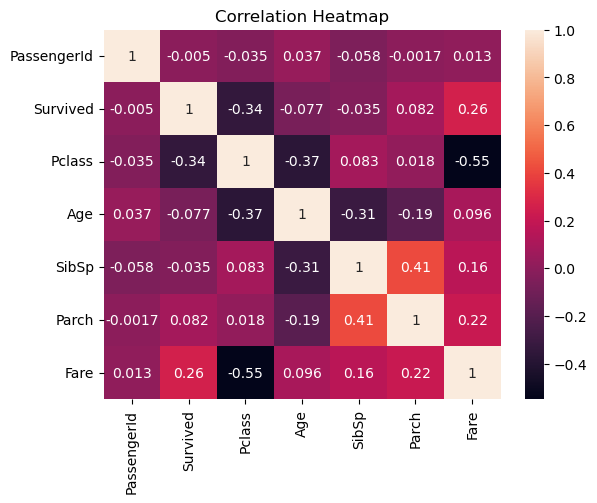

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')
plt.show()

# Heatmap for Class and Gender Survival

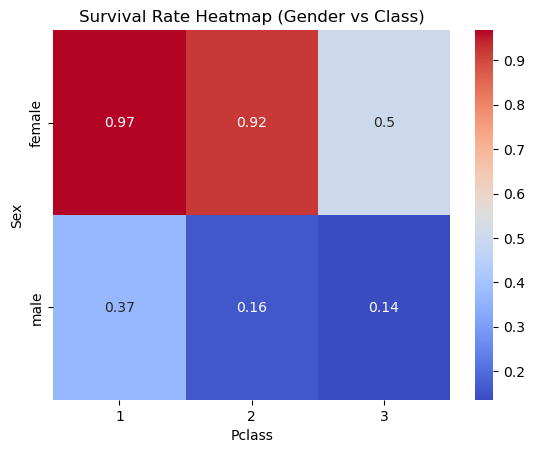

In [19]:
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass')

sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title('Survival Rate Heatmap (Gender vs Class)')
plt.show()